In [1]:
import sys

import importlib
import numpy as np
import os

# Remontée de deux niveaux pour accéder à Data_loader
current_dir = os.getcwd()
project_root = os.path.normpath(os.path.join(current_dir, "..", ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Chemin du projet : {project_root}")

Chemin du projet : /home/loai/Documents/code/RSMLExtraction/RSA_deep_working


In [2]:
from __future__ import annotations

import os
from pathlib import Path
from typing import Dict
from Data_loader import dataloaders
import numpy as np
import torch
from tqdm import tqdm

OUTPUT_DIR = Path("/home/loai/Documents/code/RSMLExtraction/RSA_deep_working/TDA/output")

In [3]:
base_directory = "/home/loai/data/UC1_data"
img_transform = None
mask_transform_image = None
mask_transform_series = None

# Create loaders
train_loader, val_loader, test_loader, val_loader_series, test_loader_series = dataloaders.create_dataloader(
    base_directory,
    img_transform=img_transform,
    mask_transform_image=mask_transform_image,
    mask_transform_series=mask_transform_series,
    num_workers=8)

Nombre de séries : 29
Nombre d'images (toutes séries confondues) : 841

Number of Training series : 20
Number of Validation series : 5
Number of Testing series : 4

Number of Training images : 580
Number of Validation images : 145
Number of Testing images : 116



Image shape: torch.Size([29, 1166, 1348])
Mask shape: torch.Size([29, 1166, 1348])
Times shape: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28])
MTG paths: 29


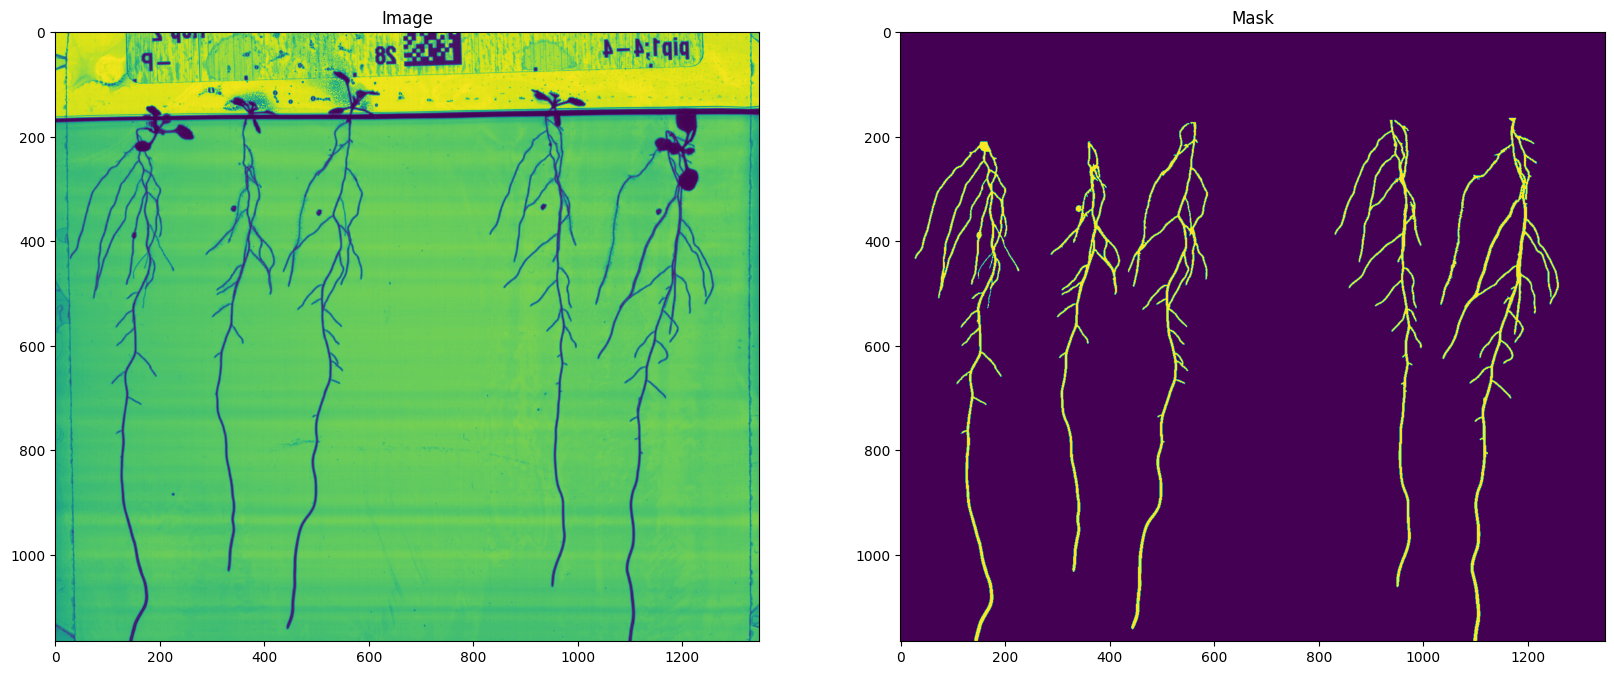

In [4]:
# load and show one image from val_loader
batch = next(iter(val_loader_series))
imgs, masks, times, mtg_paths = batch
print(f"Image shape: {imgs.shape}")
print(f"Mask shape: {masks.shape}")
print(f"Times shape: {times}")
print(f"MTG paths: {len(mtg_paths)}")

# show last image
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(imgs[-1, :, :])
plt.title("Image")
plt.subplot(1, 2, 2)
plt.imshow(masks[-1, :, :])
plt.title("Mask")
plt.show()

## Complexe cubique

In [7]:
import numpy as np
import gudhi as gd
from scipy.ndimage import distance_transform_edt


class PersistenceMetric():
    type = "cpu"

    def __init__(
        self,
        homology_dimensions=(0, 1),
        complex_builder=None,
        filter_fn=None,
    ):
        """
        - homology_dimensions : tuple des dimensions d'homologie à considérer (ex. (0,1)).
        - complex_builder : fonction data -> complexe GUDHI  
            (ex. lambda data: gd.CubicalComplex(top_dimensional_cells=data))
        - filter_fn : fonction data -> data filtrée  
            (ex. pour superlevel sets, lambda d: d.max() - d)
        """
        super().__init__()
        self.homology_dimensions = homology_dimensions
        # builder par défaut : CubicalComplex en sous-niveau
        self.complex_builder = complex_builder or (
            lambda data: gd.CubicalComplex(top_dimensional_cells=data)
        )
        # filter par défaut : pas de transformation
        self.filter_fn = filter_fn or (
            lambda data: distance_transform_edt(data > 0)
        )

    def _compute_diagram(self, array: np.ndarray):
        # applique le filtre puis construit le complexe et calcule la persistance
        data = self.filter_fn(array.astype(np.float32))
        complex_ = self.complex_builder(data)
        complex_.compute_persistence()
        return complex_.persistence()

    def __call__(self, prediction: np.ndarray, mask: np.ndarray) -> float:
        # calcule diagrammes
        diag_pred = self._compute_diagram(prediction)
        diag_msk  = self._compute_diagram(mask)

        # bottleneck par dimension
        distances = []
        for dim in self.homology_dimensions:
            dgm_pred = [(b, d) for dgm_dim, (b, d) in diag_pred if dgm_dim == dim]
            dgm_msk  = [(b, d) for dgm_dim, (b, d) in diag_msk  if dgm_dim == dim]
            distances.append(gd.bottleneck_distance(dgm_pred, dgm_msk))
        return float(np.mean(distances))

    def plot(self, prediction: np.ndarray, mask: np.ndarray):
        import matplotlib.pyplot as plt

        diag_pred = self._compute_diagram(prediction)
        diag_msk  = self._compute_diagram(mask)

        gd.plot_persistence_diagram(diag_pred, legend="Prediction")
        gd.plot_persistence_diagram(diag_msk,  legend="Mask")
        plt.show()

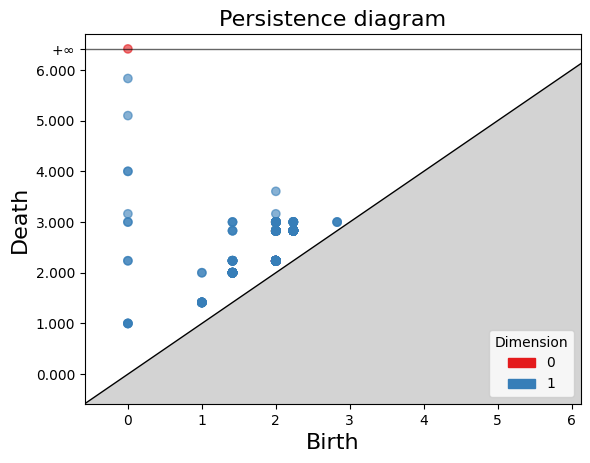

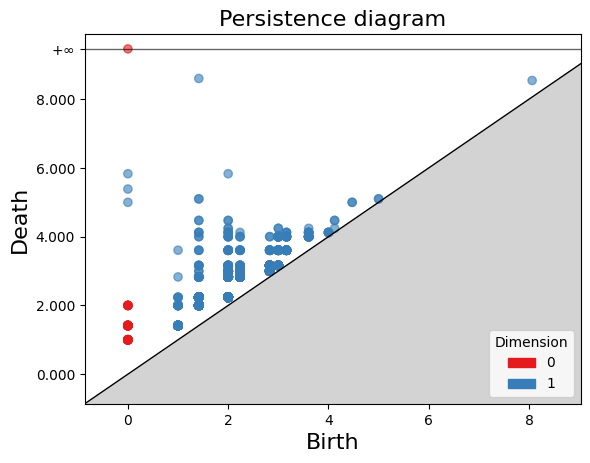

In [13]:
persistence_metric = PersistenceMetric(homology_dimensions=(0, 1))
persistence_metric.plot(masks[-20, :, :].numpy(), masks[-1, :, :].numpy())

In [12]:
persistence_metric(masks[-20, :, :].numpy(), masks[-1, :, :].numpy())

1.885686686098663